<a href="https://colab.research.google.com/github/allanjfarias/PISI3/blob/main/notebooks/random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aplicação Random Forest com SMOTE

Import de bibliotecas

In [ ]:
!pip install imbalanced-learn
!pip install shap

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline
import shap

Load do DF

In [20]:
df = pd.read_csv("../datasets/spotify_processed.csv")

Random Forest + SMOTE

=== Matriz de Confusão ===
[[14606  7142]
 [ 1029  1627]]


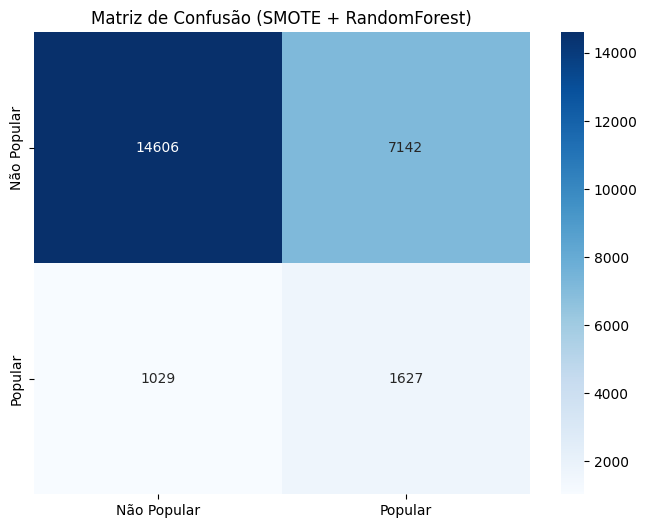


=== Métricas Detalhadas ===
              precision    recall  f1-score   support

 Não Popular       0.93      0.67      0.78     21748
     Popular       0.19      0.61      0.28      2656

    accuracy                           0.67     24404
   macro avg       0.56      0.64      0.53     24404
weighted avg       0.85      0.67      0.73     24404


=== Validação Cruzada ===
Acurácia média: 0.6605 (± 0.0024)

=== Overfitting Check ===
Acurácia Treino: 0.6743
Acurácia Teste: 0.6652
Diferença: 0.0091 (ideal < 0.1)


C:\Users\Luan D' Miranda\AppData\Local\Temp\ipykernel_12076\3865443343.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette='viridis',


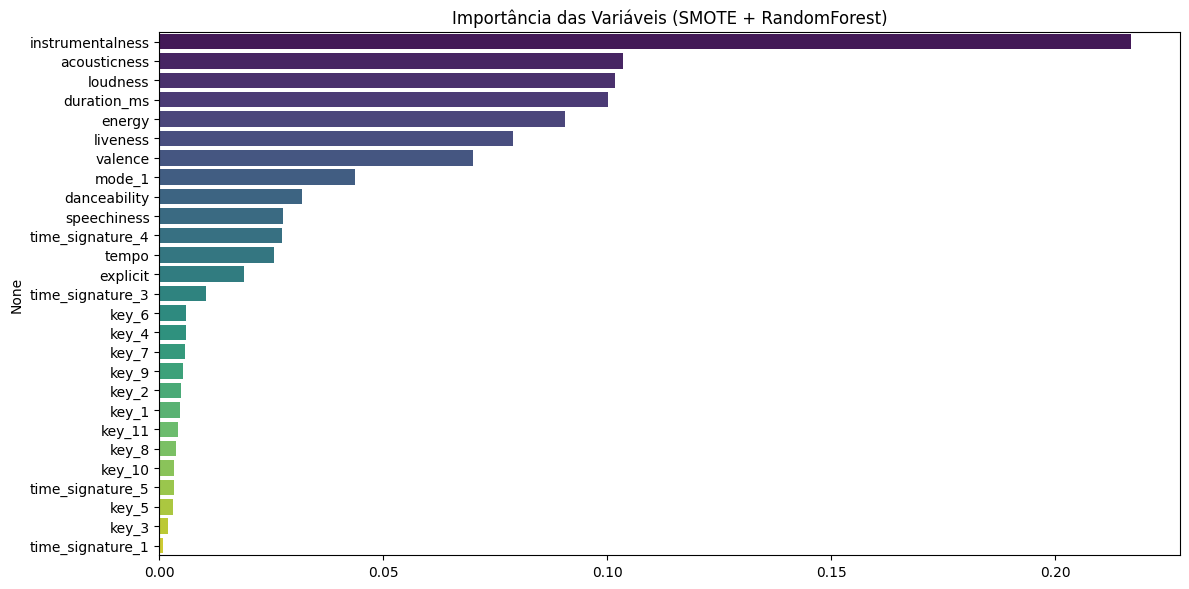

In [21]:
# Carregar os dados
new_df = df.copy()
X = new_df.drop(columns=['is_popular'])
y = new_df['is_popular']

# Dividir em treino e teste (SMOTE NUNCA deve ser aplicado no teste!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Criar pipeline com SMOTE + RandomForest otimizado
model = make_pipeline(
    SMOTE(random_state=42),  # Aplicado apenas durante o treino
    RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
)

# Treinar o modelo
model.fit(X_train, y_train)

# Avaliar no conjunto de teste
y_pred = model.predict(X_test)

# Matriz de Confusão
conf_matrix = confusion_matrix(y_test, y_pred)
print("=== Matriz de Confusão ===")
print(conf_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Popular', 'Popular'],
            yticklabels=['Não Popular', 'Popular'])
plt.title('Matriz de Confusão (SMOTE + RandomForest)')
plt.show()

# Relatório de Classificação
print("\n=== Métricas Detalhadas ===")
print(classification_report(y_test, y_pred, target_names=['Não Popular', 'Popular']))

# Validação Cruzada (5 folds)
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print("\n=== Validação Cruzada ===")
print(f"Acurácia média: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")

# Comparação Treino vs Teste
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
print("\n=== Overfitting Check ===")
print(f"Acurácia Treino: {train_acc:.4f}")
print(f"Acurácia Teste: {test_acc:.4f}")
print(f"Diferença: {train_acc - test_acc:.4f} (ideal < 0.1)")

# Importância das Variáveis (acessar o modelo dentro do pipeline)
rf_model = model.named_steps['randomforestclassifier']
importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(12,6))
sns.barplot(x=importances, y=features, palette='viridis', 
            order=features[np.argsort(importances)[::-1]])
plt.title('Importância das Variáveis (SMOTE + RandomForest)')
plt.tight_layout()
plt.show()

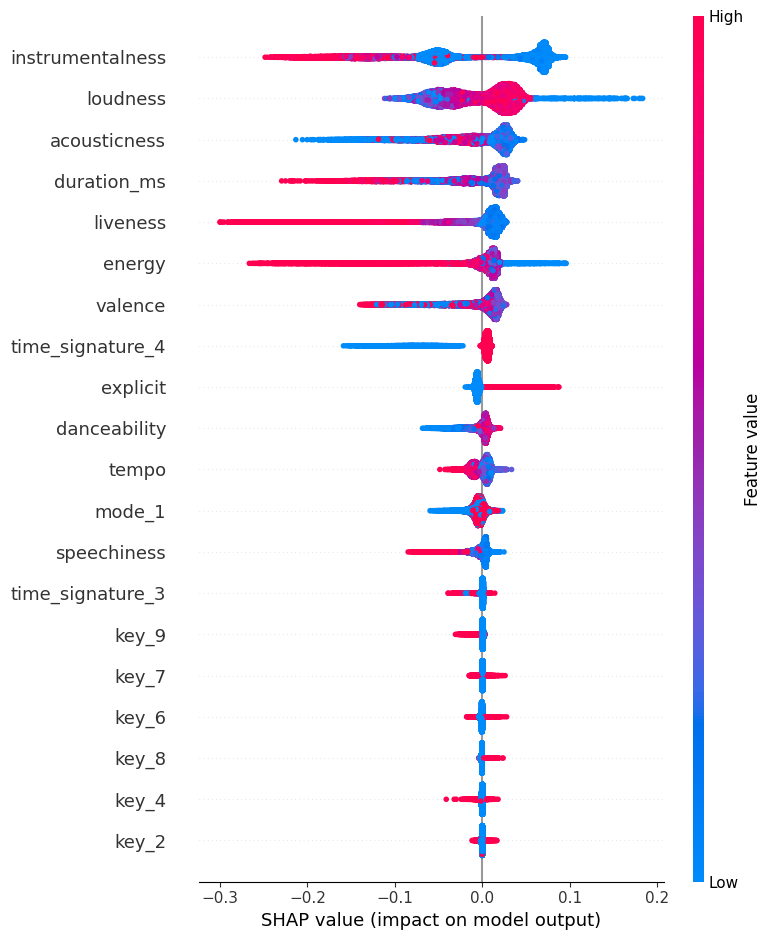

In [28]:
# Explicador para modelos de árvore (TreeExplainer)
explainer = shap.TreeExplainer(rf_model)

# Usar apenas X_test (sem SMOTE) para explicações
shap_values = explainer.shap_values(X_test)

# Gráfico de resumo para a classe 1 ("Popular")
# Para RandomForestClassifier binário, shap_values é (n amostras, n features, 2)
# Selecionar a classe 1 (índice 1 na última dimensão)
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=X_test.columns)